### 📚 Case Study 1: Importing Required Libraries
- **Objective:** In this cell, we import all the essential Python libraries required for data manipulation, Natural Language Processing (NLP), machine learning model training, and data visualization.
- **Key Tools:**
  - `pandas` and `numpy` for data handling.
  - `nltk` and `re` for text cleaning.
  - `sklearn` for model building, data splitting, and evaluation.
  - `matplotlib` and `seaborn` for graphical analysis.

In [1]:
import numpy as np
import pandas as pd
import joblib
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

### 📚 Case Study 2: Downloading the Dataset
- **Objective:** We use the Kaggle API (`kagglehub`) to automatically download the "Real or Fake Job Postings" dataset from the web to get the local path of the dataset file.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/real-or-fake-fake-jobposting-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'real-or-fake-fake-jobposting-prediction' dataset.
Path to dataset files: /kaggle/input/real-or-fake-fake-jobposting-prediction


### 📚 Case Study 3: Loading Data and Preview
- **Objective:** Loading the downloaded CSV file into a Pandas DataFrame (`df`) and displaying the first 5 records. This gives us a quick overview of the dataset's columns, values, and format.

In [3]:
import os
file_path = os.path.join(
    path,
    "fake_job_postings.csv"
)

df = pd.read_csv(file_path)

df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


### 📚 Case Study 4: Dataset Basic Information
- **Objective:** Running `df.info()` provides essential structural information such as the total number of rows (17,880), columns, data types, and how many missing (null) values exist in each column.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

### 📚 Case Study 5: Missing Values Analysis
- **Objective:** To find the exact count of missing values in each column. Columns like `salary_range` and `department` contain a very high volume of missing data.

In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (17880, 18)


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64


### 📚 Case Study 6: Dropping Unnecessary Features
- **Objective:** Columns that have too many missing values or are not highly informative for predicting fake jobs (e.g., `department`, `salary_range`, `benefits`, etc.) are removed from the dataset.

In [7]:
df = df.drop(columns=['department','salary_range','required_education','required_experience','benefits'])

### 📚 Case Study 7: Missing Value Imputation
- **Objective:** Handling missing values in the remaining columns. Text (object) columns are filled with the placeholder `"Unknown"`, while numerical columns are imputed using their median values.

In [8]:
for col in df.columns:

    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")

    else:
        df[col] = df[col].fillna(df[col].median())

### 📚 Case Study 8: Handling Imbalanced Data (Data Balancing)
- **Objective:** Rectifying the class imbalance between real and fake job postings. Since real jobs significantly outnumber fake ones, we sample a balanced ratio (60:40) to prevent the model from becoming biased.

In [9]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
job_id              0
title               0
location            0
company_profile     0
description         0
requirements        0
telecommuting       0
has_company_logo    0
has_questions       0
employment_type     0
industry            0
function            0
fraudulent          0
dtype: int64


In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
real_jobs = df[df["fraudulent"] == 0]
fake_jobs = df[df["fraudulent"] == 1]

# 60:40 ratio
real_count = int(len(fake_jobs) * 1.5)

real_jobs = real_jobs.sample(
    n=real_count,
    random_state=42
)

# Combine
df = pd.concat(
    [real_jobs, fake_jobs],
    ignore_index=True
)

# Shuffle
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

### 📚 Case Study 9: Visualizing Target Distribution
- **Objective:** Creating a count plot of the target variable to verify that the real (0) and fake (1) classes are now well-balanced after sampling.

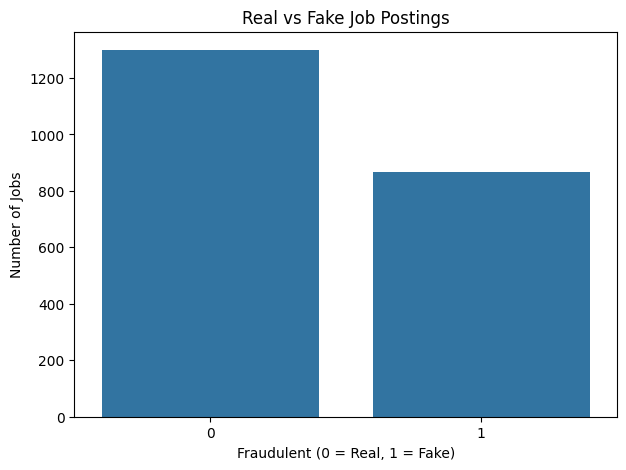

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="fraudulent"
)

plt.title("Real vs Fake Job Postings")
plt.xlabel("Fraudulent (0 = Real, 1 = Fake)")
plt.ylabel("Number of Jobs")

plt.show()

### 📚 Case Study 10: Company Logo vs. Fraudulent Postings
- **Objective:** Analyzing if companies lacking a logo are more likely to post fake jobs. The visualization clearly shows that a majority of fraudulent jobs do not feature a company logo.

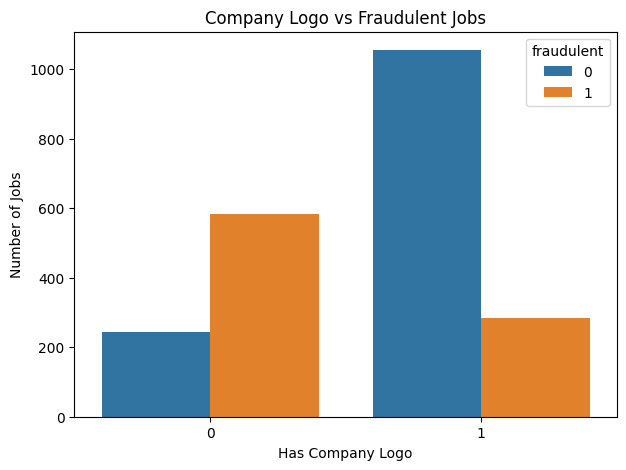

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="has_company_logo",
    hue="fraudulent"
)

plt.title("Company Logo vs Fraudulent Jobs")
plt.xlabel("Has Company Logo")
plt.ylabel("Number of Jobs")

plt.show()

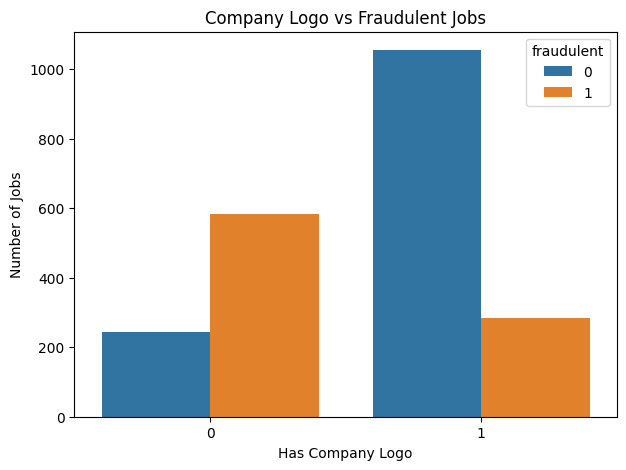

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="has_company_logo",
    hue="fraudulent"
)

plt.title("Company Logo vs Fraudulent Jobs")
plt.xlabel("Has Company Logo")
plt.ylabel("Number of Jobs")

plt.show()

### 📚 Case Study 11: Feature Engineering (Combining Text Columns)
- **Objective:** Merging multiple text-based fields (such as `title`, `description`, `requirements`, etc.) into a single consolidated column named `combined_text` for uniform NLP preprocessing.

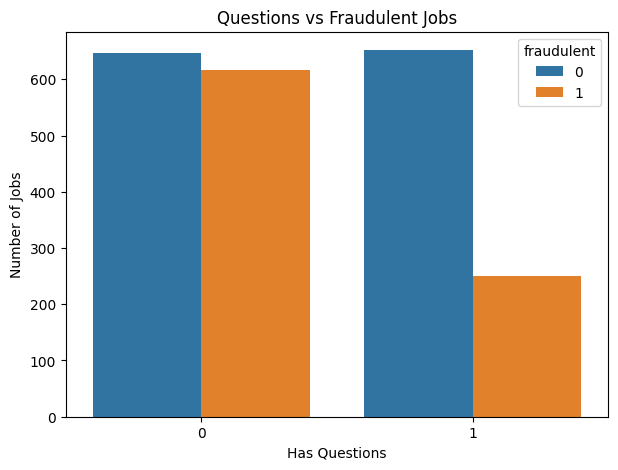

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="has_questions",
    hue="fraudulent"
)

plt.title("Questions vs Fraudulent Jobs")
plt.xlabel("Has Questions")
plt.ylabel("Number of Jobs")

plt.show()

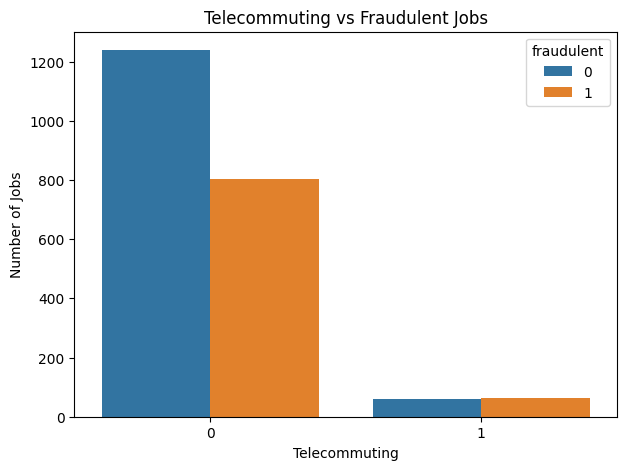

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="telecommuting",
    hue="fraudulent"
)

plt.title("Telecommuting vs Fraudulent Jobs")
plt.xlabel("Telecommuting")
plt.ylabel("Number of Jobs")

plt.show()

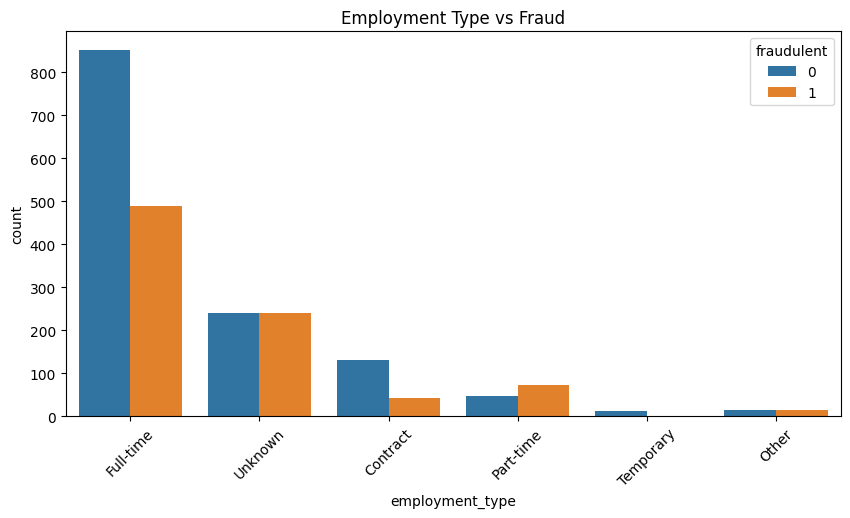

In [17]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="employment_type",
    hue="fraudulent"
)

plt.title("Employment Type vs Fraud")
plt.xticks(rotation=45)

plt.show()

In [18]:
text_columns = [
    "title",
    "location",
    "company_profile",
    "description",
    "requirements",
    "industry",
    "function"
]

print(text_columns)

['title', 'location', 'company_profile', 'description', 'requirements', 'industry', 'function']


In [19]:
df["combined_text"] = df[text_columns].astype(str).agg(" ".join, axis=1)

df[["combined_text", "fraudulent"]].head()

,combined_text,fraudulent
0,"Licensed Life Insurance Agent US, OR, Portland...",1
1,"CIVIL PROJECT ENGINEER US, TX, Houston Unknown...",1
2,"Bookkeeper FT/PT US, NY, Farmingdale Unknown G...",1
3,"Director, Supply Chain - Strategy US, OH, Cinc...",0
4,Home Based Payroll Typist/Data Entry Clerks Po...,1


### 📚 Case Study 12: Text Cleaning Function
- **Objective:** Defining a reusable helper function to clean the text data by removing URLs, HTML tags, special characters, numbers, and extra whitespaces, and converting everything to lowercase.

In [20]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

### 📚 Case Study 13: Applying Text Cleaning
- **Objective:** Applying our custom cleaning function to the `combined_text` column to produce a highly standardized, noise-free text feature called `clean_text`.

In [21]:
df["clean_text"] = df["combined_text"].apply(clean_text)

df[["combined_text", "clean_text"]].head()

,combined_text,clean_text
0,"Licensed Life Insurance Agent US, OR, Portland...",licensed life insurance agent us or portland u...
1,"CIVIL PROJECT ENGINEER US, TX, Houston Unknown...",civil project engineer us tx houston unknown j...
2,"Bookkeeper FT/PT US, NY, Farmingdale Unknown G...",bookkeeper ft pt us ny farmingdale unknown gpn...
3,"Director, Supply Chain - Strategy US, OH, Cinc...",director supply chain strategy us oh cincinnat...
4,Home Based Payroll Typist/Data Entry Clerks Po...,home based payroll typist data entry clerks po...


### 📚 Case Study 14: Train-Test Split
- **Objective:** Splitting the dataset into training (80%) and testing (20%) sets. We use `stratify=y` to ensure that both splits retain the exact same ratio of real and fake postings.

In [22]:
X = df["clean_text"]
y = df["fraudulent"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2165,)
y shape: (2165,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1732,)
Testing data: (433,)


### 📚 Case Study 15: Text Vectorization (TF-IDF)
- **Objective:** Since machine learning models cannot understand raw words, we use Term Frequency-Inverse Document Frequency (TF-IDF) to convert the textual features into highly informative numerical matrices.

In [24]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=20000
)

### 📚 Case Study 16: Model Training (Linear Support Vector Classifier)
- **Objective:** Initializing and fitting a `LinearSVC` model using the training data. This Support Vector Machine variant is highly optimized for fast and accurate high-dimensional text classification.

In [25]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (1732, 20000)
Test TF-IDF shape: (433, 20000)


In [26]:
print("Training classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

Training classes:
fraudulent
0    1039
1     693
Name: count, dtype: int64

Testing classes:
fraudulent
0    260
1    173
Name: count, dtype: int64


In [27]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=10000,
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

LinearSVC(class_weight='balanced', max_iter=10000, random_state=42)

### 📚 Case Study 17: Model Evaluation
- **Objective:** Making predictions on unseen test data and generating key performance evaluation metrics, including accuracy score, a comprehensive classification report (precision, recall, F1-score), and a confusion matrix heatmap.

In [28]:
y_pred = svm_model.predict(X_test_tfidf)

In [29]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 94.0 %


In [30]:

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       260
           1       0.94      0.91      0.92       173

    accuracy                           0.94       433
   macro avg       0.94      0.93      0.94       433
weighted avg       0.94      0.94      0.94       433



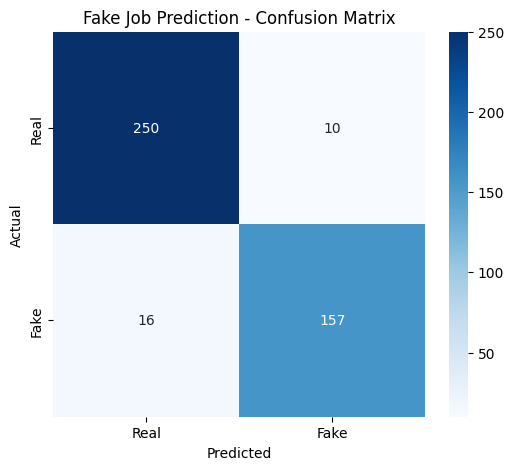

In [31]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fake Job Prediction - Confusion Matrix")

plt.show()

### 📚 Case Study 18: Model Saving and Serialization
- **Objective:** Saving the trained `LinearSVC` model and the `TF-IDF` vectorizer as `.joblib` files, allowing us to load and deploy them in the future without repeating the training process.

In [32]:
# Save TF-IDF Vectorizer
joblib.dump(
    tfidf,
    "fake_job_tfidf.joblib"
)

# Save trained SVM Model
joblib.dump(
    svm_model,
    "fake_job_svm_model.joblib"
)

print("✅ TF-IDF Vectorizer saved successfully!")
print("✅ SVM Model saved successfully!")

✅ TF-IDF Vectorizer saved successfully!
✅ SVM Model saved successfully!


In [33]:
tfidf = joblib.load("fake_job_tfidf.joblib")
svm_model = joblib.load("fake_job_svm_model.joblib")

print("✅ Model and TF-IDF loaded successfully!")

✅ Model and TF-IDF loaded successfully!


In [34]:
df

,job_id,title,location,company_profile,description,requirements,telecommuting,has_company_logo,has_questions,employment_type,industry,function,fraudulent,combined_text,clean_text
0,5363,Licensed Life Insurance Agent,"US, OR, Portland",Unknown,"We need someone who is smart, funny, great wit...",Unknown,0,1,1,Full-time,Insurance,Sales,1,"Licensed Life Insurance Agent US, OR, Portland...",licensed life insurance agent us or portland u...
1,6686,CIVIL PROJECT ENGINEER,"US, TX, Houston",Unknown,Job Responsibilities;The Project Engineer is r...,ob QualificationsBachelors degree in Civil Eng...,0,0,0,Full-time,Oil & Energy,Engineering,1,"CIVIL PROJECT ENGINEER US, TX, Houston Unknown...",civil project engineer us tx houston unknown j...
2,4676,Bookkeeper FT/PT,"US, NY, Farmingdale",Unknown,"GPN, an optometric consulting firm, is seeking...",Tasks and Accountabilities Post daily auto pay...,0,0,0,Unknown,"Health, Wellness and Fitness",Accounting/Auditing,1,"Bookkeeper FT/PT US, NY, Farmingdale Unknown G...",bookkeeper ft pt us ny farmingdale unknown gpn...
3,13993,"Director, Supply Chain - Strategy","US, OH, Cincinnati",We Provide Full Time Permanent Positions for m...,(We have more than 1500 Job openings in our we...,Unknown,0,0,0,Full-time,Market Research,Unknown,0,"Director, Supply Chain - Strategy US, OH, Cinc...",director supply chain strategy us oh cincinnat...
4,5523,Home Based Payroll Typist/Data Entry Clerks Po...,"US, NJ, Absecon",Unknown,We have several openings available in this are...,"Basic computer and typing skills, ability to s...",0,0,0,Unknown,Unknown,Unknown,1,Home Based Payroll Typist/Data Entry Clerks Po...,home based payroll typist data entry clerks po...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2160,7149,CUSTOMER SERVICE REP,"US, TX, DALLAS",Our globally connected world has forced busine...,DescriptionDUTIES INCLUDE BUT ARE NOT LIMITED ...,RequirementsCommunication - communicates clear...,0,1,1,Full-time,Telecommunications,Customer Service,1,"CUSTOMER SERVICE REP US, TX, DALLAS Our global...",customer service rep us tx dallas our globally...
2161,15754,Community & Marketing Manager,"GB, , London",Wheely provides you with a flawless private dr...,Become part of the inspired Wheely team in Lon...,Your main task is to increase the number of ac...,0,1,1,Full-time,"Leisure, Travel & Tourism",Marketing,0,"Community & Marketing Manager GB, , London Whe...",community marketing manager gb london wheely p...
2162,11672,Customer Service Representatives,"US, NY, Farmingdale","For over 20 years NAC Marketing Company, LLC d...",• Answer both incoming customer service calls ...,• 6 months work experience • High school diplo...,0,1,0,Full-time,Unknown,Customer Service,0,"Customer Service Representatives US, NY, Farmi...",customer service representatives us ny farming...
2163,11830,Delivery Services Manager,"US, WI, St. Cloud","ABC Supply Co., Inc. is the nation’s largest w...","As a Delivery Services Manager, you will be in...","As a Delivery Services Manager, you must have ...",0,1,0,Full-time,Building Materials,Unknown,0,"Delivery Services Manager US, WI, St. Cloud AB...",delivery services manager us wi st cloud abc s...
